## Cleaning implant keypoints from .csv had .h5 colledtedData files from the trainingAgression project

In [1]:
import socket, torch
print(socket.gethostname())
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU")

node067
True
NVIDIA A100-SXM4-80GB


In [2]:
import deeplabcut
import pandas as pd
from pathlib import Path
import os

/proj/berzelius-2026-203/users/x_migro/envs/deeplabcut/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def remove_individual_and_change_scorer(df, new_scorer, individual_to_remove):
    """
    Removes all keypoints for one individual, e.g. intruder mouse,
    and changes the scorer name.
    """

    # Find individual level
    if "individuals" in df.columns.names:
        individual_level = "individuals"
    else:
        # In most maDLC files, level 0 = scorer, level 1 = individuals
        individual_level = 1

    # Remove all columns belonging to the chosen individual
    individuals = df.columns.get_level_values(individual_level).astype(str)

    keep = individuals.str.lower() != individual_to_remove.lower()
    df = df.loc[:, keep]

    # Replace scorer level, usually level 0
    new_columns = []
    for col in df.columns:
        col = list(col)
        col[0] = new_scorer
        new_columns.append(tuple(col))

    df.columns = pd.MultiIndex.from_tuples(
        new_columns,
        names=df.columns.names
    )

    return df

In [ ]:
folder = Path(
    r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topView_DLC\trainingAggression_unifiedDataset-StefanosStagkourakis&MiguelRocha-2026-06-24\labeled-data"
)

new_scorer = "StefanosStagkourakis&MiguelRocha"

# Change this to the exact individual name used in your DLC config/data
individual_to_remove = "Implant"

for csv_path in folder.rglob("CollectedData_*.csv"):
    old_h5_path = csv_path.with_suffix(".h5")

    final_csv_path = csv_path.with_name(f"CollectedData_{new_scorer}.csv")
    final_h5_path = csv_path.with_name(f"CollectedData_{new_scorer}.h5")

    tmp_csv_path = csv_path.with_name(f"__tmp__CollectedData_{new_scorer}.csv")
    tmp_h5_path = csv_path.with_name(f"__tmp__CollectedData_{new_scorer}.h5")

    print(f"\nProcessing: {csv_path.parent}")

    # ----- CSV -----
    # maDLC usually has 4 column header levels:
    # scorer / individuals / bodyparts / coords
    df_csv = pd.read_csv(
        csv_path,
        header=[0, 1, 2, 3],
        index_col=[0, 1, 2]
    )

    print("CSV column levels:", df_csv.columns.names)
    print("Individuals found:", sorted(set(df_csv.columns.get_level_values(1).astype(str))))

    df_csv = remove_individual_and_change_scorer(
        df_csv,
        new_scorer,
        individual_to_remove
    )

    df_csv.to_csv(tmp_csv_path)
    os.replace(tmp_csv_path, final_csv_path)

    if csv_path != final_csv_path and csv_path.exists():
        csv_path.unlink()

    print(f"Saved/overwritten CSV as: {final_csv_path.name}")

    # ----- H5 -----
    if old_h5_path.exists():
        with pd.HDFStore(old_h5_path, "r") as store:
            keys = store.keys()

        if len(keys) == 0:
            print(f"WARNING: no H5 keys found in {old_h5_path.name}")
            continue

        h5_key = keys[0].lstrip("/")
        df_h5 = pd.read_hdf(old_h5_path, key=h5_key)

        print("H5 column levels:", df_h5.columns.names)
        print("Individuals found:", sorted(set(df_h5.columns.get_level_values(1).astype(str))))

        df_h5 = remove_individual_and_change_scorer(
            df_h5,
            new_scorer,
            individual_to_remove
        )

        df_h5.to_hdf(tmp_h5_path, key=h5_key, mode="w")

        os.replace(tmp_h5_path, final_h5_path)

        if old_h5_path != final_h5_path and old_h5_path.exists():
            old_h5_path.unlink()

        print(f"Saved/overwritten H5 as: {final_h5_path.name}")
    else:
        print("No matching H5 found.")


Processing: C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topView_DLC\trainingAggression_unifiedDataset-StefanosStagkourakis&MiguelRocha-2026-06-24\labeled-data\mouse1010819_Day02_topView_comp
Saved/overwritten CSV as: CollectedData_StefanosStagkourakis&MiguelRocha.csv
Saved/overwritten H5 as: CollectedData_StefanosStagkourakis&MiguelRocha.h5

Processing: C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topView_DLC\trainingAggression_unifiedDataset-StefanosStagkourakis&MiguelRocha-2026-06-24\labeled-data\mouse1010819_Day04_topView_comp
Saved/overwritten CSV as: CollectedData_StefanosStagkourakis&MiguelRocha.csv
Saved/overwritten H5 as: CollectedData_StefanosStagkourakis&MiguelRocha.h5

Processing: C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topView_DLC\trainingAggression_unifiedDataset-StefanosStagkourakis&MiguelRocha-2026-06-24\labeled-data\mouse1010819_Day05_topView

C:\Users\stagk\AppData\Local\Temp\ipykernel_7980\1012942579.py:51: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42) have mixed types. Specify dtype option on import or set low_memory=False.
  df_csv = pd.read_csv(csv_path, header=[0, 1, 2], index_col=[0, 1, 2])


Saved/overwritten CSV as: CollectedData_StefanosStagkourakis&MiguelRocha.csv
Saved/overwritten H5 as: CollectedData_StefanosStagkourakis&MiguelRocha.h5

Processing: C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topView_DLC\trainingAggression_unifiedDataset-StefanosStagkourakis&MiguelRocha-2026-06-24\labeled-data\mouse975833_Day05__topView_comp
Saved/overwritten CSV as: CollectedData_StefanosStagkourakis&MiguelRocha.csv
Saved/overwritten H5 as: CollectedData_StefanosStagkourakis&MiguelRocha.h5

Processing: C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topView_DLC\trainingAggression_unifiedDataset-StefanosStagkourakis&MiguelRocha-2026-06-24\labeled-data\mouse975833_Day06_topView_comp
Saved/overwritten CSV as: CollectedData_StefanosStagkourakis&MiguelRocha.csv
Saved/overwritten H5 as: CollectedData_StefanosStagkourakis&MiguelRocha.h5

Processing: C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSe

# Super animal model

In [12]:
import os
import deeplabcut
from deeplabcut.modelzoo import build_weight_init, utils
from deeplabcut.utils import auxiliaryfunctions

superanimal_name = "superanimal_topviewmouse"
config_path = Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topView_DLC\trainingAggression_unifiedDataset-StefanosStagkourakis&MiguelRocha-2026-06-24\config.yaml")

More info: https://huggingface.co/mwmathis/DeepLabCutModelZoo-SuperAnimal-TopViewMouse

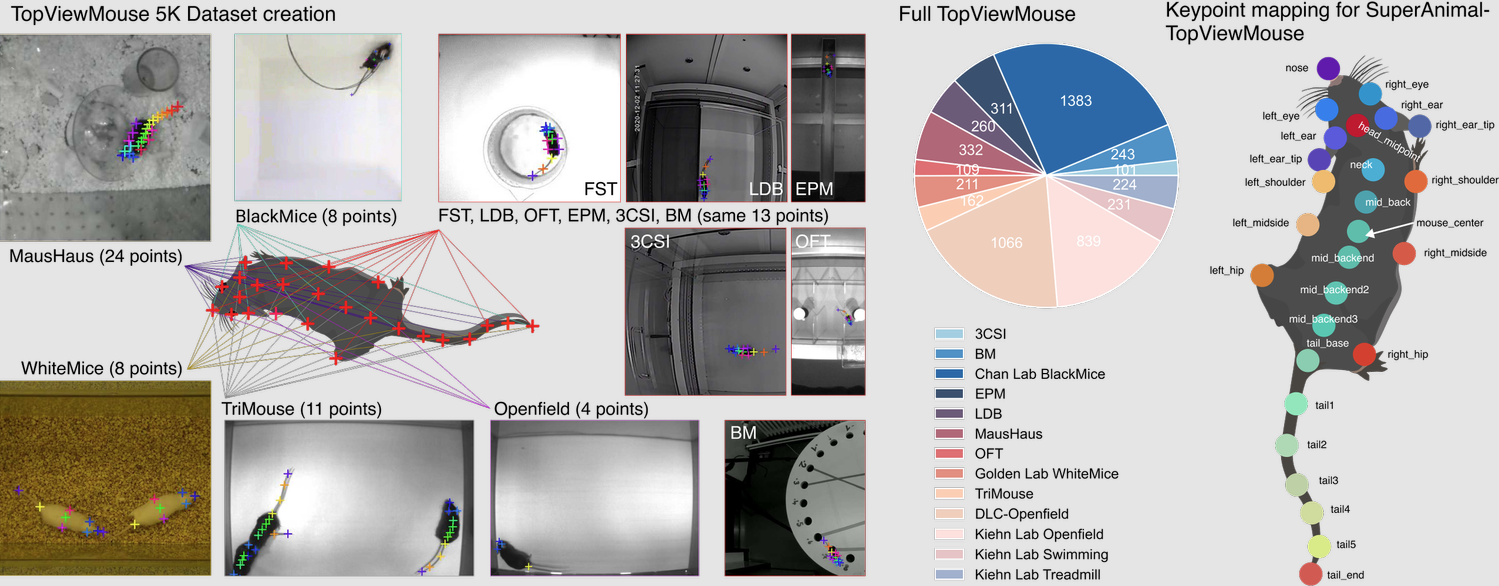

In [14]:
cfg = auxiliaryfunctions.read_config(config_path)
print(cfg["multianimalbodyparts"])

sa_cfg = utils.get_super_animal_project_cfg(superanimal_name)
print(sa_cfg["bodyparts"])



['nose', 'rightEar', 'leftEar', 'neckBase', 'betNeckBaseAndMidPoint', 'midPoint', 'betMidPointAndTailBase', 'tailBase', 'tailMid', 'tailTip']
['nose', 'left_ear', 'right_ear', 'left_ear_tip', 'right_ear_tip', 'left_eye', 'right_eye', 'neck', 'mid_back', 'mouse_center', 'mid_backend', 'mid_backend2', 'mid_backend3', 'tail_base', 'tail1', 'tail2', 'tail3', 'tail4', 'tail5', 'left_shoulder', 'left_midside', 'left_hip', 'right_shoulder', 'right_midside', 'right_hip', 'tail_end', 'head_midpoint']


In [15]:
project_to_super_animal = {
    "nose": "nose",
    "leftEar": "left_ear",
    "rightEar": "right_ear",
    "neckBase": "neck",
    "betNeckBaseAndMidPoint": "mid_back",
    "midPoint": "mouse_center",
    "betMidPointAndTailBase": "mid_backend2",
    "tailBase": "tail_base",
    "tailMid": "tail3",
    "tailTip": "tail_end"
}


utils.create_conversion_table(
    config_path,
    superanimal_name,
    project_to_super_animal
)

ConversionTable(super_animal='superanimal_topviewmouse', project_bodyparts=['nose', 'rightEar', 'leftEar', 'neckBase', 'betNeckBaseAndMidPoint', 'midPoint', 'betMidPointAndTailBase', 'tailBase', 'tailMid', 'tailTip'], super_animal_bodyparts=['nose', 'left_ear', 'right_ear', 'left_ear_tip', 'right_ear_tip', 'left_eye', 'right_eye', 'neck', 'mid_back', 'mouse_center', 'mid_backend', 'mid_backend2', 'mid_backend3', 'tail_base', 'tail1', 'tail2', 'tail3', 'tail4', 'tail5', 'left_shoulder', 'left_midside', 'left_hip', 'right_shoulder', 'right_midside', 'right_hip', 'tail_end', 'head_midpoint'], table={'nose': 'nose', 'leftEar': 'left_ear', 'rightEar': 'right_ear', 'neckBase': 'neck', 'betNeckBaseAndMidPoint': 'mid_back', 'midPoint': 'mouse_center', 'betMidPointAndTailBase': 'mid_backend2', 'tailBase': 'tail_base', 'tailMid': 'tail3', 'tailTip': 'tail_end'})

In [53]:
new_shuffle = 1   

weight_init = build_weight_init(
    cfg=config_path,
    super_animal=superanimal_name,
    model_name="resnet_50",
    detector_name="fasterrcnn_resnet50_fpn_v2",
    with_decoder=True,
)

deeplabcut.create_training_dataset(
    config_path,
    Shuffles=[new_shuffle],
    weight_init=weight_init,
)


Duplicate entries: 
  * C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topView_DLC\trainingAggression_unifiedDataset-StefanosStagkourakis&MiguelRocha-2026-06-24\videos\mouse52_Day06.mp4
  * C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topView_DLC\trainingAggression_unifiedDataset-StefanosStagkourakis&MiguelRocha-2026-06-24\videos\analyzedVideos_it0_shuffle2\topView_DLCtracking_pcutoff_0.6_skeleton\mouse52_Day06.mp4
Duplicate entries: 
  * C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topView_DLC\trainingAggression_unifiedDataset-StefanosStagkourakis&MiguelRocha-2026-06-24\videos\mouse53_Day06.mp4
  * C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topView_DLC\trainingAggression_unifiedDataset-StefanosStagkourakis&MiguelRocha-2026-06-24\videos\analyzedVideos_it0_shuffle2\topView_DLCtracking_pcutoff_0.6_skeleton\mouse53_Day06.mp4
Du

C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topView_DLC\trainingAggression_unifiedDataset-StefanosStagkourakis&MiguelRocha-2026-06-24\labeled-data\mouse975833_Day04__topView_comp\CollectedData_StefanosStagkourakis&MiguelRocha.h5  not found (perhaps not annotated).
Utilizing the following graph: [[0, 1], [0, 2], [0, 3], [0, 4], [0, 5], [0, 6], [0, 7], [0, 8], [0, 9], [1, 2], [1, 3], [1, 4], [1, 5], [1, 6], [1, 7], [1, 8], [1, 9], [2, 3], [2, 4], [2, 5], [2, 6], [2, 7], [2, 8], [2, 9], [3, 4], [3, 5], [3, 6], [3, 7], [3, 8], [3, 9], [4, 5], [4, 6], [4, 7], [4, 8], [4, 9], [5, 6], [5, 7], [5, 8], [5, 9], [6, 7], [6, 8], [6, 9], [7, 8], [7, 9], [8, 9]]
Creating training data for: Shuffle: 1 TrainFraction:  0.95


100%|██████████| 616/616 [00:00<00:00, 17590.61it/s]

The training dataset is successfully created. Use the function 'train_network' to start training. Happy training!


In [54]:
deeplabcut.train_network(
    config_path,
    shuffle=new_shuffle,
    epochs=20,
    save_epochs = 5,
    superanimal_name=superanimal_name,
    batch_size=32,
    superanimal_transfer_learning=True,
)

Training with configuration:
data:
  colormode: RGB
  inference:
    normalize_images: True
  train:
    affine:
      p: 0.5
      rotation: 30
      scaling: [0.5, 1.25]
      translation: 0
    crop_sampling:
      width: 448
      height: 448
      max_shift: 0.1
      method: hybrid
    gaussian_noise: 12.75
    motion_blur: True
    normalize_images: True
device: auto
inference:
  multithreading:
    enabled: True
    queue_length: 4
    timeout: 30.0
  compile:
    enabled: False
    backend: inductor
  autocast:
    enabled: False
metadata:
  project_path: C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topView_DLC\trainingAggression_unifiedDataset-StefanosStagkourakis&MiguelRocha-2026-06-24
  pose_config_path: C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topView_DLC\trainingAggression_unifiedDataset-StefanosStagkourakis&MiguelRocha-2026-06-24\dlc-models-pytorch\iteration-1\trainingAggression_unified

# Personalized multi-animal model (inference) - Trained with the GUI

In [68]:
import time

new_shuffle = 3   

videos_folder = Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\Stefanos_RIdataset")
#videos = [str(f) for f in videos_folder.rglob("*.mp4")]
videos = [r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\Stefanos_RIdataset\20190805_60males\20190806_ri2ndConditioning_60males\20190806_V6_Top_cropped_rois\mouse52_Day02.mp4",
          r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\Stefanos_RIdataset\20190805_60males\20190807_ri3rdConditioning_60males\20190807_V6_Top_cropped_rois\mouse52_Day03.mp4",
          r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\Stefanos_RIdataset\20190805_60males\20190808_ri4thConditioning_60males\20190808_V6_Top_cropped_rois\mouse52_Day04.mp4"]
savePath = Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\Stefanos_RIdataset_DLC")

pcutoff = 0.8
tracking_method = "skeleton"

for v in videos:

    start_T = time.time()

    video_path = Path(v)
    video_name = video_path.name

    # Example: mouse4901_Day01.mp4 -> mouse4901
    mouse_id = video_path.stem.split("_Day")[0]

    print("\n") 
    print(f"============================= {video_name} =============================")
    print(f"Mouse ID: {mouse_id}")

    # Create mouse-specific folder
    mouse_folder = savePath / mouse_id 

    # DLC outputs for all days of this mouse go here
    destFolder = mouse_folder / f"topView_DLCtracking_pcutoff_{pcutoff}_{tracking_method}"

    destFolder.mkdir(parents=True, exist_ok=True)

    deeplabcut.analyze_videos(
        config_path,
        str(video_path),
        videotype=".mp4",
        shuffle=new_shuffle,
        auto_track=True,
        identity_only=True,
        dynamic=(False, .5, 10),
        destfolder=str(destFolder)
    )
                                               
    deeplabcut.filterpredictions(
        config_path, 
        str(video_path), 
        videotype=".mp4", 
        shuffle=new_shuffle,
        filtertype="median",
        windowlength=5,
        track_method=tracking_method,
        destfolder=str(destFolder)
    )

    deeplabcut.plot_trajectories(
        config_path, 
        str(video_path), 
        shuffle=new_shuffle, 
        filtered=True, 
        track_method=tracking_method,
        destfolder=str(destFolder)
    )

    deeplabcut.create_labeled_video(
        config_path, 
        str(video_path), 
        videotype=".mp4", 
        shuffle=new_shuffle, 
        filtered=True, 
        fastmode=True, 
        save_frames=False, 
        keypoints_only=False, 
        Frames2plot=None, 
        displayedbodyparts="all", 
        displayedindividuals="all",
        outputframerate=None, 
        draw_skeleton=True, 
        trailpoints=0, 
        displaycropped=False, 
        track_method=tracking_method,
        dotsize=3,
        destfolder=str(destFolder),
        skeleton_color="red",
        confidence_to_alpha=True,
        plot_bboxes=False, 
        pcutoff=pcutoff,
        color_by="individual"
    )
    
    stop_T = time.time()

    print(f"Processing time: {((stop_T - start_T) / 60):.2f} min\n")



============================= mouse52_Day02.mp4 =============================
Mouse ID: mouse52
Analyzing videos with C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topView_DLC\trainingAggression_unifiedDataset-StefanosStagkourakis&MiguelRocha-2026-06-24\dlc-models-pytorch\iteration-3\trainingAggression_unifiedDatasetJun24-trainset95shuffle3\train\snapshot-best-130.pt
Using scorer: DLC_Resnet101_trainingAggression_unifiedDatasetJun24shuffle3_snapshot_best-130
Starting to analyze C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\Stefanos_RIdataset\20190805_60males\20190806_ri2ndConditioning_60males\20190806_V6_Top_cropped_rois\mouse52_Day02.mp4
Video metadata: 
  Overall # of frames:    9000
  Duration of video [s]:  900.00
  fps:                    10.0
  resolution:             w=260, h=540

Running pose prediction with batch size 16


  1%|          | 95/9000 [00:00<01:19, 112.63it/s]d:\Anaconda3\envs\DEEPLABCUT\Lib\site-packages\deeplabcut\pose_estimation_pytorch\data\postprocessor.py:514: RuntimeWarning: invalid value encountered in cast
  heatmap_indices = np.rint(individual_keypoints).astype(int)
100%|██████████| 9000/9000 [07:31<00:00, 19.95it/s]


Processing...  C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\Stefanos_RIdataset\20190805_60males\20190806_ri2ndConditioning_60males\20190806_V6_Top_cropped_rois\mouse52_Day02.mp4
Loading From C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\Stefanos_RIdataset_DLC\mouse52\topView_DLCtracking_pcutoff_0.8_skeleton\mouse52_Day02DLC_Resnet101_trainingAggression_unifiedDatasetJun24shuffle3_snapshot_best-130.h5


100%|██████████| 9000/9000 [00:02<00:00, 3460.28it/s]


The tracklets were created (i.e., under the hood deeplabcut.convert_detections2tracklets was run). Now you can 'refine_tracklets' in the GUI, or run 'deeplabcut.stitch_tracklets'.
Processing...  C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\Stefanos_RIdataset\20190805_60males\20190806_ri2ndConditioning_60males\20190806_V6_Top_cropped_rois\mouse52_Day02.mp4


...

The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.

Filtering with median model C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\Stefanos_RIdataset\20190805_60males\20190808_ri4thConditioning_60males\20190808_V6_Top_cropped_rois\mouse52_Day04.mp4
Saving filtered csv poses!
Loading  C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\Stefanos_RIdataset\20190805_60males\20190808_ri4thConditioning_60males\20190808_V6_Top_cropped_rois\mouse52_Day04.mp4 and data.
Plots created! Please check the directory "plot-poses" within the video directory
Starting to process video: C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\Stefanos_RIdataset\20190805_60males\20190808_ri4thConditioni

d:\Anaconda3\envs\DEEPLABCUT\Lib\site-packages\deeplabcut\utils\make_labeled_video.py:146: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  Dataframe.groupby(level="individuals", axis=1).size().values // 3


Duration of video [s]: 900.0, recorded with 10.0 fps!
Overall # of frames: 9000 with cropped frame dimensions: 284 530
Generating frames and creating video.


100%|██████████| 9000/9000 [01:11<00:00, 125.68it/s]


Processing time: 9.05 min



## Single animal model

In [74]:
def convert_to_single_animal(df, new_scorer, individual_to_keep):
    """
    Convert maDLC format:
        scorer / individuals / bodyparts / coords

    into standard DLC format:
        scorer / bodyparts / coords
    """

    if df.columns.nlevels != 4:
        raise ValueError(
            f"Expected 4 column levels for maDLC, got {df.columns.nlevels}: {df.columns.names}"
        )

    if "individuals" in df.columns.names:
        individual_level = df.columns.names.index("individuals")
    else:
        individual_level = 1

    individuals = df.columns.get_level_values(individual_level).astype(str)
    available_individuals = sorted(set(individuals))

    print("Available individuals:", available_individuals)

    if individual_to_keep not in available_individuals:
        raise ValueError(
            f"Could not find individual '{individual_to_keep}'. "
            f"Available individuals: {available_individuals}"
        )

    # Keep only Resident
    df = df.loc[:, individuals == individual_to_keep]

    new_columns = []

    for col in df.columns:
        # Original:
        # scorer / individuals / bodyparts / coords
        scorer = new_scorer
        bodypart = col[2]
        coord = col[3]

        new_columns.append((scorer, bodypart, coord))

    df.columns = pd.MultiIndex.from_tuples(
        new_columns,
        names=["scorer", "bodyparts", "coords"]
    )

    return df

### Adapt previously labeled data from other projects to a new project

In [75]:

folder = Path(
    r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topview_DLC_singleAnimal\unifiedDataset_topView_DLC--StefanosStagkourakis&MiguelRocha-2026-07-06\labeled-data"
)

new_scorer = "-StefanosStagkourakis&MiguelRocha"
individual_to_keep = "Resident"


for csv_path in folder.rglob("CollectedData_*.csv"):
    h5_path = csv_path.with_suffix(".h5")

    print(f"\nProcessing folder: {csv_path.parent}")
    print(f"CSV: {csv_path.name}")

    # Read maDLC CSV
    df_csv = pd.read_csv(
        csv_path,
        header=[0, 1, 2, 3],
        index_col=[0, 1, 2]
    )

    print("Before CSV column levels:", df_csv.columns.names)

    df_csv = convert_to_single_animal(
        df_csv,
        new_scorer=new_scorer,
        individual_to_keep=individual_to_keep
    )

    print("After CSV column levels:", df_csv.columns.names)

    final_csv_path = csv_path.with_name(f"CollectedData_{new_scorer}.csv")
    tmp_csv_path = csv_path.with_name(f"__tmp__CollectedData_{new_scorer}.csv")

    df_csv.to_csv(tmp_csv_path)
    os.replace(tmp_csv_path, final_csv_path)

    if csv_path != final_csv_path and csv_path.exists():
        csv_path.unlink()

    print(f"Saved single-animal CSV: {final_csv_path.name}")

    # Convert matching H5 if present
    if h5_path.exists():
        print(f"H5: {h5_path.name}")

        with pd.HDFStore(h5_path, "r") as store:
            keys = store.keys()

        if len(keys) == 0:
            print(f"WARNING: no H5 keys found in {h5_path.name}")
            continue

        h5_key = keys[0].lstrip("/")
        df_h5 = pd.read_hdf(h5_path, key=h5_key)

        print("Before H5 column levels:", df_h5.columns.names)

        df_h5 = convert_to_single_animal(
            df_h5,
            new_scorer=new_scorer,
            individual_to_keep=individual_to_keep
        )

        print("After H5 column levels:", df_h5.columns.names)

        final_h5_path = h5_path.with_name(f"CollectedData_{new_scorer}.h5")
        tmp_h5_path = h5_path.with_name(f"__tmp__CollectedData_{new_scorer}.h5")

        # Standard DLC usually uses this key
        df_h5.to_hdf(tmp_h5_path, key="df_with_missing", mode="w")
        os.replace(tmp_h5_path, final_h5_path)

        if h5_path != final_h5_path and h5_path.exists():
            h5_path.unlink()

        print(f"Saved single-animal H5: {final_h5_path.name}")
    else:
        print("No matching H5 found.")


Processing folder: C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topview_DLC_singleAnimal\unifiedDataset_topView_DLC--StefanosStagkourakis&MiguelRocha-2026-07-06\labeled-data\mouse1010819_Day02_topView_comp
CSV: CollectedData_-StefanosStagkourakis&MiguelRocha.csv
Before CSV column levels: ['scorer', 'individuals', 'bodyparts', 'coords']
Available individuals: ['Resident']
After CSV column levels: ['scorer', 'bodyparts', 'coords']
Saved single-animal CSV: CollectedData_-StefanosStagkourakis&MiguelRocha.csv
H5: CollectedData_-StefanosStagkourakis&MiguelRocha.h5
Before H5 column levels: ['scorer', 'individuals', 'bodyparts', 'coords']
Available individuals: ['Resident']
After H5 column levels: ['scorer', 'bodyparts', 'coords']
Saved single-animal H5: CollectedData_-StefanosStagkourakis&MiguelRocha.h5

Processing folder: C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topview_DLC_singleAnimal\unifiedDataset_topV

## Train model

In [3]:
config_path = r"/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unifiedDataset_topView_DLC--StefanosStagkourakis&MiguelRocha-2026-07-06/config.yaml"

new_shuffle = 3
net_type = "resnet_101"

In [ ]:
# 2. Create/recreate training dataset
deeplabcut.create_training_dataset(
    config_path,
    num_shuffles=new_shuffle,
    net_type = net_type
)

# 3. Train network
deeplabcut.train_network(
    config_path,
    shuffle=new_shuffle,
    trainingsetindex=0,
    device="cuda:0",      # use "cpu" or None if no GPU, depending on DLC version
    epochs=200,
    save_epochs=5,
    max_snapshots_to_keep=5,
)

Duplicate entries: 
  * C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topView_DLC\trainingAggression_unifiedDataset-StefanosStagkourakis&MiguelRocha-2026-06-24\videos\mouse52_Day06.mp4
  * C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topView_DLC\trainingAggression_unifiedDataset-StefanosStagkourakis&MiguelRocha-2026-06-24\videos\analyzedVideos_it0_shuffle2\topView_DLCtracking_pcutoff_0.6_skeleton\mouse52_Day06.mp4
Duplicate entries: 
  * C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topView_DLC\trainingAggression_unifiedDataset-StefanosStagkourakis&MiguelRocha-2026-06-24\videos\mouse53_Day06.mp4
  * C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topView_DLC\trainingAggression_unifiedDataset-StefanosStagkourakis&MiguelRocha-2026-06-24\videos\analyzedVideos_it0_shuffle2\topView_DLCtracking_pcutoff_0.6_skeleton\mouse53_Day06.mp4
Du

/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unifiedDataset_topView_DLC--StefanosStagkourakis&MiguelRocha-2026-07-06/labeled-data/mouse975833_Day04__topView_comp/CollectedData_-StefanosStagkourakis&MiguelRocha.h5  not found (perhaps not annotated).


Training with configuration:
data:
  bbox_margin: 20
  colormode: RGB
  inference:
    normalize_images: True
  train:
    affine:
      p: 0.5
      rotation: 30
      scaling: [0.5, 1.25]
      translation: 0
    crop_sampling:
      width: 448
      height: 448
      max_shift: 0.1
      method: hybrid
    gaussian_noise: 12.75
    motion_blur: True
    normalize_images: True
device: auto
inference:
  multithreading:
    enabled: True
    queue_length: 4
    timeout: 30.0
  compile:
    enabled: False
    backend: inductor
  autocast:
    enabled: False
metadata:
  project_path: /proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unifiedDataset_topView_DLC--StefanosStagkourakis&MiguelRocha-2026-07-06
  pose_config_path: /proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unifiedDataset_topView_DLC--StefanosStagkourakis&MiguelRocha-2026-07-06/dlc-models-pytorch/iteration-1/unifiedDataset_topView_DLCJul6-trainset95shuffle

## Inference on all RI datasets

In [ ]:
deeplabcut.evaluate_network(
    config_path,
    shuffles=[new_shuffle],
    trainingsetindex=0,
    plotting=True,
    per_keypoint_evaluation=True,
    device="cuda:0",
)

In [8]:

videos_folder_D1 = Path(
    "/proj/berzelius-2026-203/users/x_migro/data/"
    "unifiedDataset_topview_DLC_singleAnimal/Stefanos_RIdataset"
)

videos_folder_D2 = Path(
    "/proj/berzelius-2026-203/users/x_migro/data/"
    "unifiedDataset_topview_DLC_singleAnimal/maladapivePreScreening"
)

savePath_D1 = Path(
    "/proj/berzelius-2026-203/users/x_migro/data/"
    "unifiedDataset_topview_DLC_singleAnimal/Stefanos_RIdataset_DLC_singleAnimal"
)

savePath_D2 = Path(
    "/proj/berzelius-2026-203/users/x_migro/data/"
    "unifiedDataset_topview_DLC_singleAnimal/maladapivePreScreening_DLC_singleAnimal"
)

videos = (
    list(videos_folder_D1.rglob("*.mp4"))
    + list(videos_folder_D2.rglob("*.mp4"))
)

videos = [r"/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/maladapivePreScreening/20251215_16males_MR/20260107_V5_H2_cropped_rois/mouse1034805_Day005.mp4"]


================ mouse1034805_Day005.mp4 ================
Dataset: maladapivePreScreening
Mouse ID: mouse1034805
Destination: /proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/maladapivePreScreening_DLC_singleAnimal/mouse1034805/topView_DLCtracking_pcutoff_0.65_skeleton
Analyzing videos with /proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unifiedDataset_topView_DLC--StefanosStagkourakis&MiguelRocha-2026-07-06/dlc-models-pytorch/iteration-1/unifiedDataset_topView_DLCJul6-trainset95shuffle3/train/snapshot-best-150.pt
Using scorer: DLC_Resnet101_unifiedDataset_topView_DLCJul6shuffle3_snapshot_best-150
Starting to analyze /proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/maladapivePreScreening/20251215_16males_MR/20260107_V5_H2_cropped_rois/mouse1034805_Day005.mp4
Video metadata: 
  Overall # of frames:    22080
  Duration of video [s]:  736.00
  fps:                    30.0
  resolutio

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22080/22080 [01:02<00:00, 352.85it/s]


Saving results in /proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/maladapivePreScreening_DLC_singleAnimal/mouse1034805/topView_DLCtracking_pcutoff_0.65_skeleton/mouse1034805_Day005DLC_Resnet101_unifiedDataset_topView_DLCJul6shuffle3_snapshot_best-150.h5 and /proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/maladapivePreScreening_DLC_singleAnimal/mouse1034805/topView_DLCtracking_pcutoff_0.65_skeleton/mouse1034805_Day005DLC_Resnet101_unifiedDataset_topView_DLCJul6shuffle3_snapshot_best-150_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.

Filtering with median model /proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/malad

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22080/22080 [00:58<00:00, 378.43it/s]


Processing time: 2.16 min


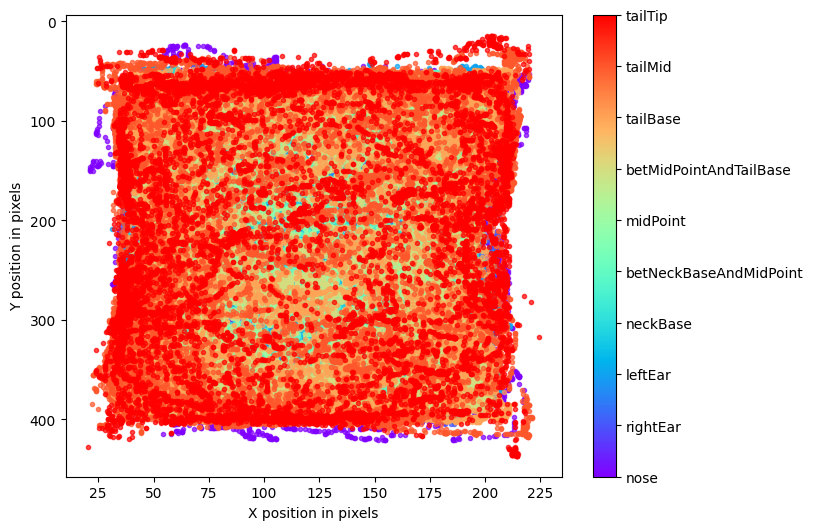

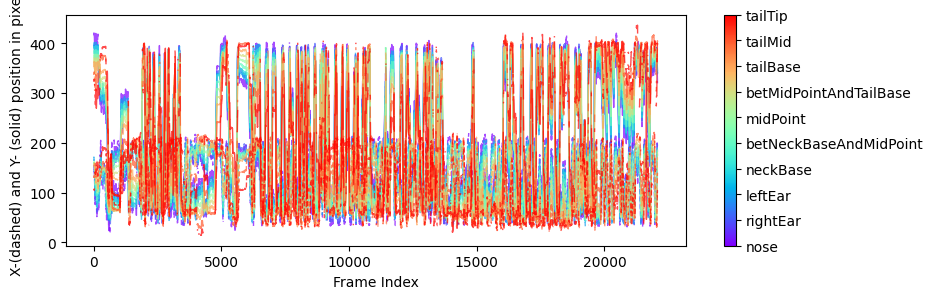

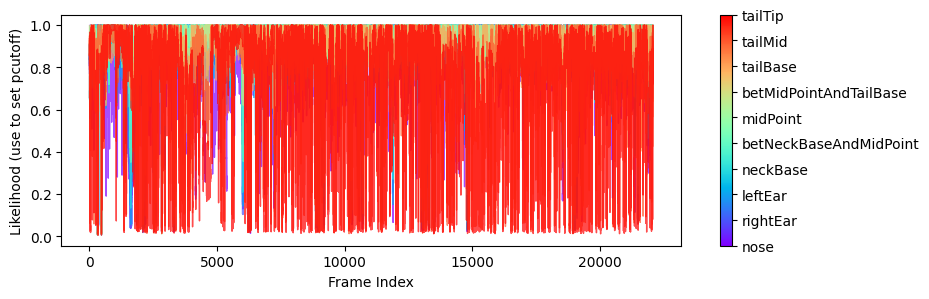

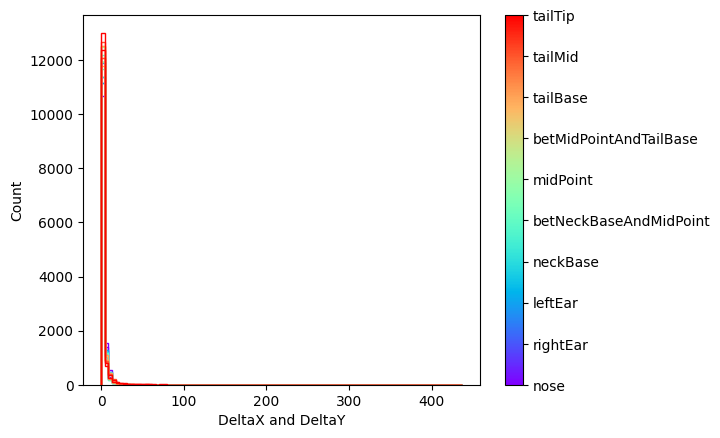

In [10]:
import time

pcutoff = 0.65
tracking_method = "skeleton"

for video_path in videos:

    start_T = time.time()

    video_path = Path(video_path)
    video_name = video_path.name
    mouse_id = video_path.stem.split("_Day")[0]

    if video_path.is_relative_to(videos_folder_D1):
        dataset_name = "Stefanos_RIdataset"
        savePath = savePath_D1

    elif video_path.is_relative_to(videos_folder_D2):
        dataset_name = "maladapivePreScreening"
        savePath = savePath_D2

    else:
        raise ValueError(f"Unknown source dataset for: {video_path}")

    mouse_folder = savePath / mouse_id

    destFolder = (
        mouse_folder
        / f"topView_DLCtracking_pcutoff_{pcutoff}_{tracking_method}"
    )

    destFolder.mkdir(parents=True, exist_ok=True)

    print()
    print(f"================ {video_name} ================")
    print(f"Dataset: {dataset_name}")
    print(f"Mouse ID: {mouse_id}")
    print(f"Destination: {destFolder}")

    deeplabcut.analyze_videos(
        config_path,
        str(video_path),
        videotype=".mp4",
        shuffle=new_shuffle,
        auto_track=True,
        identity_only=True,
        dynamic=(False, 0.5, 10),
        destfolder=str(destFolder),
    )

    deeplabcut.filterpredictions(
        config_path,
        str(video_path),
        video_extensions=".mp4",
        shuffle=new_shuffle,
        filtertype="median",
        windowlength=5,
        track_method=tracking_method,
        destfolder=str(destFolder),
    )

    deeplabcut.plot_trajectories(
        config_path,
        str(video_path),
        shuffle=new_shuffle,
        filtered=True,
        track_method=tracking_method,
        destfolder=str(destFolder),
    )

    deeplabcut.create_labeled_video(
        config_path,
        str(video_path),
        video_extensions=".mp4",
        shuffle=new_shuffle,
        filtered=True,
        fastmode=True,
        save_frames=False,
        keypoints_only=False,
        Frames2plot=None,
        displayedbodyparts="all",
        displayedindividuals="all",
        outputframerate=None,
        draw_skeleton=True,
        trailpoints=0,
        displaycropped=False,
        track_method=tracking_method,
        dotsize=3,
        destfolder=str(destFolder),
        skeleton_color="red",
        confidence_to_alpha=False,
        plot_bboxes=False,
        pcutoff=pcutoff,
        color_by="individual",
    )

    elapsed_minutes = (time.time() - start_T) / 60
    print(f"Processing time: {elapsed_minutes:.2f} min")